In [1]:
from ase import Atoms
from ase.visualize import view
import ase
from ase.cluster.cubic import FaceCenteredCubic
from ase.visualize import view
from matplotlib import pyplot as plt
import numpy as np
import networkx as nx
import plotly.graph_objects as go
import random

In [2]:
surfaces = [(1, 1, 0), (1, 1, 1), (1, 1, 1)]
layers = [3, 3, 3]
lc = 3.9296
cluster = FaceCenteredCubic('Pt', surfaces, layers, latticeconstant=lc)

# Get atomic positions as a NumPy array
positions = cluster.get_positions()


# In the future, here we import the possible structure taken from 
#experimental image by fantastx

Node 0: (-3.9296, -1.9648, -1.9648)
Node 1: (-1.9648, -3.9296, -1.9648)
Node 2: (-1.9648, -1.9648, -3.9296)
Node 3: (-3.9296, -1.9648, 1.9647999999999999)
Node 4: (-1.9648, -3.9296, 1.9647999999999999)
Node 5: (-1.9648, -1.9648, 0.0)
Node 6: (-1.9648, -1.9648, 3.9296)
Node 7: (-3.9296, 1.9647999999999999, -1.9648)
Node 8: (-1.9648, 0.0, -1.9648)
Node 9: (-1.9648, 1.9647999999999999, -3.9296)
Node 10: (-3.9296, 0.0, 0.0)
Node 11: (-3.9296, 1.9647999999999999, 1.9647999999999999)
Node 12: (-1.9648, 0.0, 1.9647999999999999)
Node 13: (-1.9648, 1.9647999999999999, 0.0)
Node 14: (-1.9648, 1.9647999999999999, 3.9296)
Node 15: (-1.9648, 3.9296, -1.9648)
Node 16: (-1.9648, 3.9296, 1.9647999999999999)
Node 17: (0.0, -1.9648, -1.9648)
Node 18: (1.9647999999999999, -3.9296, -1.9648)
Node 19: (1.9647999999999999, -1.9648, -3.9296)
Node 20: (0.0, -3.9296, 0.0)
Node 21: (0.0, -1.9648, 1.9647999999999999)
Node 22: (1.9647999999999999, -3.9296, 1.9647999999999999)
Node 23: (1.9647999999999999, -1.9648,

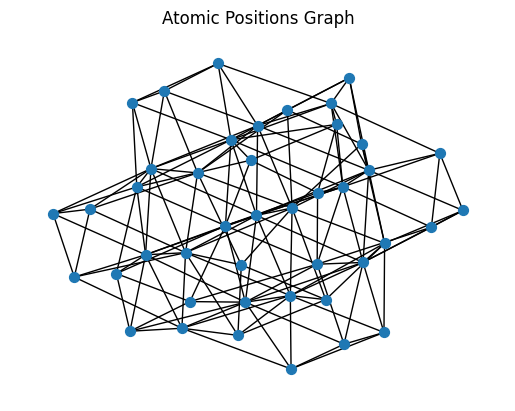


Graph G:


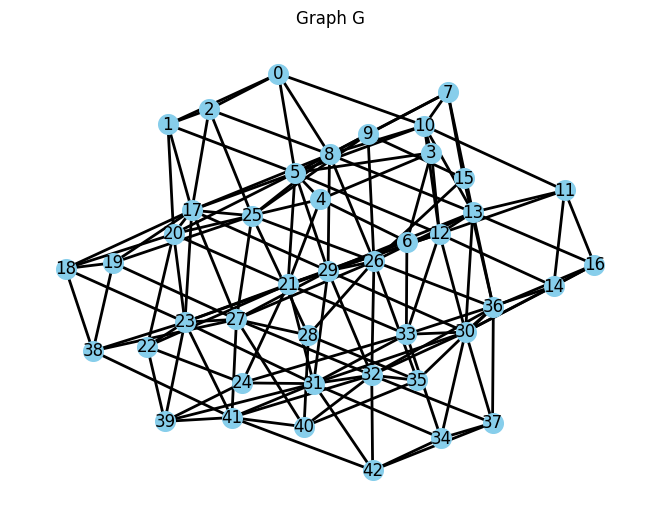

In [3]:
# Get atomic positions as a NumPy array
positions = cluster.get_positions()

# Calculate pairwise distances between atoms
distances = np.linalg.norm(positions[:, np.newaxis, :] - positions, axis=2)

# Create a graph from the distances
graph = nx.Graph()
num_atoms = len(positions)
graph.add_nodes_from(range(num_atoms))

# Define a cutoff distance for connectivity
cutoff_distance = 3.1

# Add edges for immediate neighbors based on the cutoff distance
for i in range(num_atoms):
    for j in range(i + 1, num_atoms):
        if distances[i, j] <= cutoff_distance:
            graph.add_edge(i, j, weight=distances[i, j])

# Assign coordinates to graph nodes
for node, position in zip(graph.nodes, positions):
    x_coordinate, y_coordinate, z_coordinate = position
    graph.nodes[node]['x_coordinate'] = x_coordinate
    graph.nodes[node]['y_coordinate'] = y_coordinate
    graph.nodes[node]['z_coordinate'] = z_coordinate

# Print coordinates for each node
for node in graph.nodes:
    x_coordinate = graph.nodes[node]['x_coordinate']
    y_coordinate = graph.nodes[node]['y_coordinate']
    z_coordinate = graph.nodes[node]['z_coordinate']
    print(f"Node {node}: ({x_coordinate}, {y_coordinate}, {z_coordinate})")

# Plot the graph
pos = nx.spring_layout(graph,seed=0)  # Positions for the nodes
plt.figure()
nx.draw_networkx(graph, pos=pos, with_labels=False, node_size=50)
plt.title('Atomic Positions Graph')
plt.axis('off')
plt.show()


print("\nGraph G:")
plt.figure()
pos_G = nx.spring_layout(graph, seed=0)  # Use spring layout for consistent plotting
nx.draw(graph, pos=pos_G, with_labels=True, node_color='skyblue', node_size=200, edge_color='black', width=2)
plt.title('Graph G')
plt.show()

# Plot the graph in 3D


In [201]:
# Define the cutoff distance
cutoff_distance = 3.1

# Create the cluster
surfaces = [(1, 1, 0), (1, 1, 1), (1, 1, 1)]
layers = [3, 3, 3]
lc = 3.9296
cluster = FaceCenteredCubic('Pt', surfaces, layers, latticeconstant=lc)

# Get atomic positions as a NumPy array
positions = cluster.get_positions()

# Calculate pairwise distances between atoms
distances = np.linalg.norm(positions[:, np.newaxis, :] - positions, axis=2)

# Create a graph from the distances
graph = nx.Graph()
num_atoms = len(positions)
graph.add_nodes_from(range(num_atoms))

# Add edges for immediate neighbors based on the cutoff distance
for i in range(num_atoms):
    for j in range(i + 1, num_atoms):
        if distances[i, j] <= cutoff_distance:
            graph.add_edge(i, j, weight=distances[i, j])

# Assign coordinates to graph nodes
for node, position in zip(graph.nodes, positions):
    x_coordinate, y_coordinate, z_coordinate = position
    graph.nodes[node]['x_coordinate'] = x_coordinate
    graph.nodes[node]['y_coordinate'] = y_coordinate
    graph.nodes[node]['z_coordinate'] = z_coordinate

# Get the coordinates for nodes in the graph
x_nodes = [graph.nodes[node]['x_coordinate'] for node in graph.nodes]
y_nodes = [graph.nodes[node]['y_coordinate'] for node in graph.nodes]
z_nodes = [graph.nodes[node]['z_coordinate'] for node in graph.nodes]

# Create lists holding the starting and ending coordinates of each edge in the graph
x_edges = []
y_edges = []
z_edges = []

# Fill the coordinates lists in the graph
for edge in graph.edges():
    x_coords = [graph.nodes[edge[0]]['x_coordinate'], graph.nodes[edge[1]]['x_coordinate'], None]
    x_edges += x_coords

    y_coords = [graph.nodes[edge[0]]['y_coordinate'], graph.nodes[edge[1]]['y_coordinate'], None]
    y_edges += y_coords

    z_coords = [graph.nodes[edge[0]]['z_coordinate'], graph.nodes[edge[1]]['z_coordinate'], None]
    z_edges += z_coords

# Create a trace for the edges in the graph
trace_edges = go.Scatter3d(
    x=x_edges,
    y=y_edges,
    z=z_edges,
    mode='lines',
    line=dict(color='black', width=2),
    hoverinfo='none'
)

# Create a trace for the nodes in the graph
trace_nodes = go.Scatter3d(
    x=x_nodes,
    y=y_nodes,
    z=z_nodes,
    mode='markers',
    marker=dict(symbol='circle', size=5, color='skyblue'),
    hoverinfo='text',
    text=[f'Node {node}' for node in graph.nodes]
)

# Create the figure
fig = go.Figure(data=[trace_edges, trace_nodes])

# Set layout options
fig.update_layout(
    title='3D Connections Graph',
    scene=dict(
        xaxis=dict(title='X'),
        yaxis=dict(title='Y'),
        zaxis=dict(title='Z')
    )
)

# Show the figure
fig.show()

# Plot the graph
#pos = nx.spring_layout(graph,seed=0)  # Positions for the nodes
#plt.figure()
#nx.draw_networkx(graph, pos=pos, with_labels=False, node_size=50)
#plt.title('Atomic Positions Graph')
#plt.axis('off')
#plt.show()


#print("\nGraph G:")
#plt.figure()
#pos_G = nx.spring_layout(graph, seed=0)  # Use spring layout for consistent plotting
#nx.draw(graph, pos=pos_G, with_labels=True, node_color='skyblue', node_size=200, edge_color='black', width=2)
#plt.title('Graph G')
#plt.show()



    Random Displacement: Apply random displacement to each node in the graph. You can generate random displacement values for the x, y, and z coordinates of each node and update their positions accordingly. This approach creates a more chaotic and randomized deformation.

    Harmonic Oscillation: Model the deformation of nodes as harmonic oscillators. Assign a natural frequency and amplitude to each node, and update their positions based on a sinusoidal function over time. This approach can create a wave-like deformation effect.

    Attraction and Repulsion: Simulate attraction and repulsion forces between nodes. Assign attractive forces between connected nodes and repulsive forces between non-connected nodes. Update the positions of the nodes based on the net force acting on them. This approach can lead to interesting clustering and repulsion patterns.

    Morphing: Gradually morph the graph from one structure to another. Start with an initial graph configuration and iteratively update the positions of the nodes towards the target structure. This can be achieved by interpolating between the initial and target positions over multiple iterations.



In [219]:
#Euclidean distance - once you have the H graph (perturbed) you can check euclidean node distances
def euclidean_distance_dict(graph):

# Dictionary to store the Euclidean distances
    distances_dict = {}

    # Calculate and store Euclidean distances of each node with its immediate neighbors
    for node in graph.nodes:
        neighbors = list(graph.neighbors(node))
        distances_dict[node] = {}
        for neighbor in neighbors:
            position1 = np.array([graph.nodes[node]['x_coordinate'], graph.nodes[node]['y_coordinate'], graph.nodes[node]['z_coordinate']])
            position2 = np.array([graph.nodes[neighbor]['x_coordinate'], graph.nodes[neighbor]['y_coordinate'], graph.nodes[neighbor]['z_coordinate']])
            distance = np.linalg.norm(position1 - position2)
            distances_dict[node][neighbor] = distance

    # Access the distances
    for node, neighbors in distances_dict.items():
        for neighbor, distance in neighbors.items():
            print(f"Euclidean distance between Node {node} and its neighbor {neighbor}: {distance}")

    return(distances_dict)


In [205]:
# Random (uniform) perturbation on all coordinates
# Perturb the selected nodes in H while maintaining the minimum distance constraint
def random_displacement(graph, lower_disp_limit, higher_disp_limit):
    global H
    H = graph.copy()
    perturbation = np.random.uniform(lower_disp_limit, higher_disp_limit, size=(len(graph.nodes), 3))
    for node in H.nodes:
        if all(coord in H.nodes[node] for coord in ['x_coordinate', 'y_coordinate', 'z_coordinate']):
            coordinates = np.array([
                H.nodes[node]['x_coordinate'],
                H.nodes[node]['y_coordinate'],
                H.nodes[node]['z_coordinate']
            ]) + perturbation[node]
            while any(distance < 2.0 for neighbor, distance in euclidean_distance_dict(H).get(node, {}).items() if neighbor != node):
                coordinates += np.random.uniform(-0.5, 0.5, size=3) * 0.1  # Adjust the perturbation
            H.nodes[node]['x_coordinate'], H.nodes[node]['y_coordinate'], H.nodes[node]['z_coordinate'] = coordinates
        else:
            H.nodes[node].update({
                'x_coordinate': perturbation[node][0],
                'y_coordinate': perturbation[node][1],
                'z_coordinate': perturbation[node][2]
            })
    return H



In [218]:
# Harmonic oscillation - perturbation through a trig-defined function
def harmonic_oscillation(graph, amplitude,frequency):
    global H
    H = graph.copy()
    num_nodes = len(graph.nodes)
    amplitude = amplitude
    frequency = frequency

    t = np.arange(num_nodes)  # Generate a range of time values - time steps
    displacement = amplitude * np.sin(2 * np.pi * frequency * (t / num_nodes))

    plt.plot(t, displacement)
    plt.xlabel('Time')
    plt.ylabel('Amplitude')
    plt.title('Harmonic Oscillation')
    plt.grid(True)
    plt.show()

    # Get the initial positions of the graph H
    x_initial = np.array([H.nodes[node]['x_coordinate'] for node in H.nodes])
    y_initial = np.array([H.nodes[node]['y_coordinate'] for node in H.nodes])
    z_initial = np.array([H.nodes[node]['z_coordinate'] for node in H.nodes])

    # Compute the perturbed positions by adding the displacements to the initial positions
    x_coordinates = x_initial + displacement
    y_coordinates = y_initial + displacement
    z_coordinates = z_initial + displacement

    # Update the positions of nodes in H
    #for i, node in enumerate(H.nodes):
     #   H.nodes[node]['x_coordinate'] = x_coordinates[i]
     #   H.nodes[node]['y_coordinate'] = y_coordinates[i]
     #   H.nodes[node]['z_coordinate'] = z_coordinates[i]

     # Update the positions of nodes in H while maintaining the minimum distance constraint
    for i, node in enumerate(H.nodes):
        if all(coord in H.nodes[node] for coord in ['x_coordinate', 'y_coordinate', 'z_coordinate']):
            coordinates = np.array([
                x_coordinates[i],
                y_coordinates[i],
                z_coordinates[i]
            ])
            while any(
                np.linalg.norm(
                    np.array([H.nodes[n]['x_coordinate'], H.nodes[n]['y_coordinate'], H.nodes[n]['z_coordinate']]) -
                    coordinates
                ) < 1.75 for n in H.nodes if n != node):
                perturbation = np.random.uniform(-0.2, 0.2, size=3) * 0.1  # Adjust the perturbation
                coordinates += perturbation
            H.nodes[node]['x_coordinate'] = coordinates[0]
            H.nodes[node]['y_coordinate'] = coordinates[1]
            H.nodes[node]['z_coordinate'] = coordinates[2]

    return H


In [193]:
#Attraction and repulsion function - good for making a cluster tighter or looser in order
# to investigate the influence of bonding contracting and expansion in the stability of the cluster
# can possibly be combined with random_displacement to investigate both effect
# i.e. expansion/contraction while perturbed 

import numpy as np
import networkx as nx
from scipy.optimize import minimize

def attraction_repulsion(graph, attraction_force, repulsion_force, minimum_distance):
    if not isinstance(graph, nx.Graph):
        raise ValueError("Input graph parameter must be a NetworkX graph object.")

    if attraction_force <= 0 or repulsion_force <= 0 or minimum_distance <= 0:
        raise ValueError("Force parameters must be positive numbers.")

    H = graph.copy()

    # Perturb the selected nodes in H with attraction and repulsion forces
    for node in H.nodes:
        if all(coord in H.nodes[node] for coord in ['x_coordinate', 'y_coordinate', 'z_coordinate']):
            coordinates = np.array([
                H.nodes[node]['x_coordinate'],
                H.nodes[node]['y_coordinate'],
                H.nodes[node]['z_coordinate']
            ])

            def distance_objective(coord):
                total_distance = 0.0
                penalty_distance = 0.0
                for n in H.nodes:
                    if n != node:
                        neighbor_coordinates = np.array([
                            H.nodes[n]['x_coordinate'],
                            H.nodes[n]['y_coordinate'],
                            H.nodes[n]['z_coordinate']
                        ])
                        dist = np.linalg.norm(neighbor_coordinates - coord)
                        if n in H[node]:
                            # Apply attraction force to connected nodes
                            total_distance += attraction_force * dist
                        else:
                            # Apply repulsion force to non-connected nodes
                            total_distance += repulsion_force / dist
                        if dist < minimum_distance:
                            # Penalty for distances below the minimum distance
                            penalty_distance += (minimum_distance - dist)

                return total_distance + penalty_distance

            # Perform gradient-based optimization
            result = minimize(distance_objective, coordinates, method='L-BFGS-B')
            optimized_coordinates = result.x

            # Update the coordinates
            H.nodes[node]['x_coordinate'] = optimized_coordinates[0]
            H.nodes[node]['y_coordinate'] = optimized_coordinates[1]
            H.nodes[node]['z_coordinate'] = optimized_coordinates[2]

    return H


In [129]:
# Morphing: Very specific case where one would like a structure to morph 
#into another structure. Maybe even use it in a NEB type of scenario

def morphing(graph,n_steps):

    global H
    # Create a copy of G as H
    H = graph.copy() # in this case, graph should be another structure other than the initial one

    # Define the number of morphing steps
    num_steps = n_steps

    # Create intermediate graphs between G and H
    intermediate_graphs = []
    for step in range(num_steps):
        alpha = step / (num_steps - 1)  # Interpolation factor
        intermediate_graph = nx.compose(graph, H)  # Start with a combination of G and H
        # Interpolate the positions of nodes
        for node in intermediate_graph.nodes:
            if all(coord in graph.nodes[node] and coord in H.nodes[node] for coord in ['x_coordinate', 'y_coordinate', 'z_coordinate']):
                G_position = np.array([
                    graph.nodes[node]['x_coordinate'],
                    graph.nodes[node]['y_coordinate'],
                    graph.nodes[node]['z_coordinate']
                ])
                H_position = np.array([
                    H.nodes[node]['x_coordinate'],
                    H.nodes[node]['y_coordinate'],
                    H.nodes[node]['z_coordinate']
                ])
                interpolated_position = (1 - alpha) * G_position + alpha * H_position
                intermediate_graph.nodes[node]['x_coordinate'] = interpolated_position[0]
                intermediate_graph.nodes[node]['y_coordinate'] = interpolated_position[1]
                intermediate_graph.nodes[node]['z_coordinate'] = interpolated_position[2]
        intermediate_graphs.append(intermediate_graph)


        # Apply constraint on Euclidean distances
        distances_dict = euclidean_distance_dict(intermediate_graph)
        for node, neighbors in distances_dict.items():
            for neighbor, distance in neighbors.items():
                if distance < 2.7:
                   coordinates += np.random.uniform(-0.5, 0.5, size=3) * 0.1
                else:
                    pass

        intermediate_graphs.append(intermediate_graph)


            
    return(H)




In [190]:
# Graph conversion to ASE object

def graph_to_ase_atoms(graph,H):
    
    global xyz_H, xyz_graph, graph_G, graph_H
    xyz_graph = []  # Initialize an empty list for the coordinates
    xyz_H = []
    # Iterate over the nodes in G
    for node in graph.nodes:
        if 'x_coordinate' in H.nodes[node] and 'y_coordinate' in graph.nodes[node] and 'z_coordinate' in graph.nodes[node]:
            x_coordinate = graph.nodes[node]['x_coordinate']
            y_coordinate = graph.nodes[node]['y_coordinate']
            z_coordinate = graph.nodes[node]['z_coordinate']
            
            xyz_graph.append([x_coordinate, y_coordinate, z_coordinate])

    # Create an ASE Atoms object from the coordinates
    graph_G = Atoms(symbols='Pt' * len(xyz_graph), positions=xyz_graph)

    # Print the ASE Atoms object
    print(graph_G)

    view(graph_G)


    # Iterate over the nodes in H
    for node in H.nodes:
        if 'x_coordinate' in H.nodes[node] and 'y_coordinate' in H.nodes[node] and 'z_coordinate' in H.nodes[node]:
            x_coordinate = H.nodes[node]['x_coordinate']
            y_coordinate = H.nodes[node]['y_coordinate']
            z_coordinate = H.nodes[node]['z_coordinate']
            
            xyz_H.append([x_coordinate, y_coordinate, z_coordinate])

    # Create an ASE Atoms object from the coordinates
    graph_H = Atoms(symbols='Pt' * len(xyz_H), positions=xyz_H)

    # Print the ASE Atoms object
    print(graph_H)

    view(graph_H)

    return

graph_to_ase_atoms(graph,H)

Atoms(symbols='Pt43', pbc=False)
Atoms(symbols='Pt43', pbc=False)


In [206]:
# Set the parameter values
rd = random_displacement(graph,-0.2,0.2)

three_D_plot(graph,rd)
graph_to_ase_atoms(graph,rd)

Average Euclidean Distance: 1.2910158316912217
Graph G and Graph H have different nodes.
Graph G and Graph H have the same edges.
Atoms(symbols='Pt43', pbc=False)
Atoms(symbols='Pt43', pbc=False)


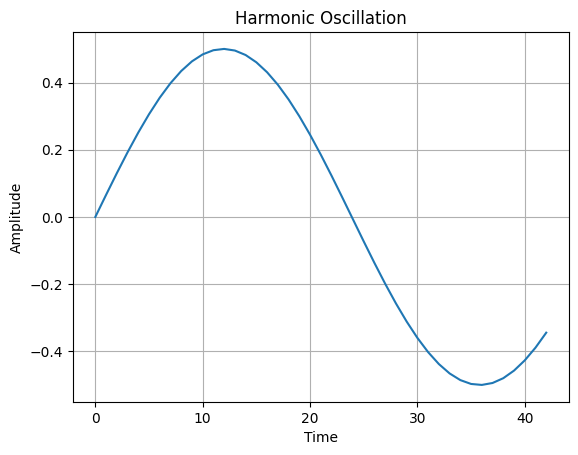

Average Euclidean Distance: 1.2089355621002773
Graph G and Graph H have different nodes.
Graph G and Graph H have the same edges.
Atoms(symbols='Pt43', pbc=False)
Atoms(symbols='Pt43', pbc=False)


In [216]:
# Set the parameter values
ho = harmonic_oscillation(graph, amplitude = .5, frequency = .9)

three_D_plot(graph,ho)
graph_to_ase_atoms(graph,ho)

In [217]:
# Set the parameter values
ar = attraction_repulsion(graph, attraction_force=0.3, repulsion_force=0.8, minimum_distance=2.6)

three_D_plot(graph,ar)
graph_to_ase_atoms(graph,ar)

Average Euclidean Distance: 1.3700918643767448
Graph G and Graph H have different nodes.
Graph G and Graph H have the same edges.
Atoms(symbols='Pt43', pbc=False)
Atoms(symbols='Pt43', pbc=False)
